## Downstream analysis for MAGs-HMM Annotation & MAGs-gtdbtk 
#### module: mags_hmm_annotation & mags_tax_annotation
HMM scores count are aggregated for all the samples using the geomosaic command:
```bash
geomosaic gather -s gmsetup.yaml -p mags_hmmsearch --mags_hmmsearch_outfolder hmm_proka_paper

```
GTDBT-k annotations and CoverM genome abundances from mags_gtdbtk and coverm_genome module are aggregated as well with:

```bash 
geomosaic gather -s gmsetup.yaml -p mags_gtdbtk
```


In [2]:
# Imports
library(phyloseq)
library(readr)
library(dplyr)
library(tidyr)
library(tidyverse)
library(stringr)
library(ggplot2)
library(ggh4x)
library(cowplot)
library(vegan)
library(pheatmap)
library(ComplexHeatmap)
library(circlize)

options(readr.show_col_types = FALSE)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ purrr     1.2.2
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: permute

Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: 

In [3]:
theme_glab <- function(base_size = 11, base_family = "") {
  theme_bw(base_size = base_size, base_family = base_family) %+replace%
    theme(
      legend.background = element_blank(),
      legend.title      = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65),
        hjust = 0
      ),
      legend.text       = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      legend.key.size   = unit(0.8, "lines"),
      plot.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        hjust = 0.5, 
        face = "bold"
      ),
      axis.title        = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      axis.text         = element_text(
        color = rgb(100, 100, 100, maxColorValue = 255),
        size = rel(0.65)
      ),
      panel.grid.major  = element_blank(),
      panel.grid.minor  = element_blank(),
      panel.border      = element_rect(
        fill = NA,
        colour = rgb(100, 100, 100, maxColorValue = 255)
      ),
      complete = TRUE
    )
}

In [4]:
sample     <- "CR18_ER180415_S"

mags_file  <- paste0("../tables/gm_gathering/mags_hmmsearch/", sample, "/mags.tsv")   # KO x MAG presence/absence
taxa_file  <- paste0("../tables/gm_gathering/mags_gtdbtk/geomosaic_samples/", sample, ".tsv")
ko_ref     <- "../tables/subset_biogeochemical_data.tsv"
output_dir <- "../figures/heatmaps/"

In [5]:
# ── Load Data ─────────────────────────────────────────────────────────────────
ko_table  <- read.delim(mags_file, header = TRUE, sep = "\t")
mag_taxa  <- read.delim(taxa_file, header = TRUE, sep = "\t")
table_ko  <- read.delim(ko_ref, header = TRUE, sep = "\t")

# ── Clean taxonomy: fill blank/NA family ─────────────────────────────────────
mag_taxa <- mag_taxa %>%
  mutate(family = if_else(is.na(family) | family == "", "Unclassified", family))

# ── KO reference ──────────────────────────────────────────────────────────────
filters <- c("Sulfur", "Carbon fixation", "Nitrogen", "O2 respiration")
target_functions <- c(filters, "Other Pathways")


In [6]:
kegg_ref <- table_ko %>%
  filter(!is.na(Cycle), Cycle != "", !is.na(Pathway), Pathway != "") %>%
  select(KO, Cycle, Pathway, gene) %>%
  distinct(KO, .keep_all = TRUE) %>%
  mutate(Cycle = if_else(Cycle %in% filters, Cycle, "Other Pathways"))


target_pathways <- kegg_ref %>%
  arrange(match(Cycle, target_functions), Pathway) %>%
  pull(Pathway) %>% unique()


In [7]:
# ── Pivot presence/absence to long, collapse to pathway level ───────────────
pa_long <- ko_table %>%
  rename(ko = HMM_model) %>%
  mutate(across(-ko, ~ as.integer(. != 0))) %>%     # force strict 0/1
  filter(ko %in% kegg_ref$KO) %>%
  pivot_longer(-ko, names_to = "mag", values_to = "presence") %>%
  left_join(kegg_ref, by = c("ko" = "KO")) %>%
  left_join(mag_taxa %>% select(MAGs, family, classification),
            by = c("mag" = "MAGs")) %>%
  filter(!is.na(Cycle)) %>%
  group_by(mag, pathway = Pathway, cycle = Cycle, family, classification) %>%
  summarise(presence = as.integer(any(presence == 1)), .groups = "drop") %>%   # pathway present if ANY of its KOs is present
  mutate(
    cycle    = factor(cycle,   levels = target_functions),
    pathway  = factor(pathway, levels = target_pathways),
    family   = factor(family),
    mag      = factor(mag),
    presence = factor(presence, levels = c(0, 1), labels = c("Absent", "Present"))
  )

In [8]:
# ── Cycle colour palette (strip backgrounds; unrelated to fill scale below) ──
cycle_colors <- c(
  "Sulfur"            = "#E69F00",
  "Carbon fixation"   = "#56B4E9",
  "Nitrogen"          = "#009E73",
  "O2 respiration"    = "#D55E00",
  "Other Pathways"    = "grey60"
)

In [9]:
options(repr.plot.width = 18, repr.plot.height = 8)

In [10]:
p_pa <- ggplot(pa_long, aes(
  x    = mag,
  y    = pathway,
  fill = presence
)) +
  geom_tile(color = "white", linewidth = 0.15) +
  facet_nested(
    cycle + pathway ~ family,
    scales    = "free",
    space     = "free",
    nest_line = element_line(linewidth = 0.4),
    solo_line = TRUE,
    strip = strip_nested(
      background_y = c(
        lapply(unname(cycle_colors[levels(pa_long$cycle)]), function(col)
          element_rect(fill = col, color = NA)
        ),
        lapply(seq_along(levels(pa_long$pathway)), function(i)
          element_rect(fill = "grey90", color = "grey70")
        )
      ),
      text_y = list(
        element_text(face = "bold", size = 10, angle = 0, hjust = 0, color = "black"),
        element_text(face = "bold", size = 10, angle = 0, hjust = 0, color = "black")
      )
    )
  ) +
  scale_fill_manual(
    values = c("Absent" = "white", "Present" = "#2C7BB6"),
    name   = "Pathway presence",
    drop   = FALSE
  ) +
  theme_glab() +
  theme(
    axis.text.x           = element_text(angle = 45, hjust = 1, vjust = 1, size = 10),
    axis.text.y            = element_text(size = 10),
    axis.title             = element_text(face = "bold", size = 13),
    ggh4x.facet.nestline    = element_line(colour = "grey60"),
    strip.background.x     = element_blank(),
    strip.text.x           = element_text(size = 10, angle = 90, hjust = 0, vjust  = 1, face = "italic"),
    panel.spacing           = unit(0.3, "lines"),
    legend.position         = "right",
    strip.clip = "off"
  ) +
  labs(x = "MAG", y = "Gene")

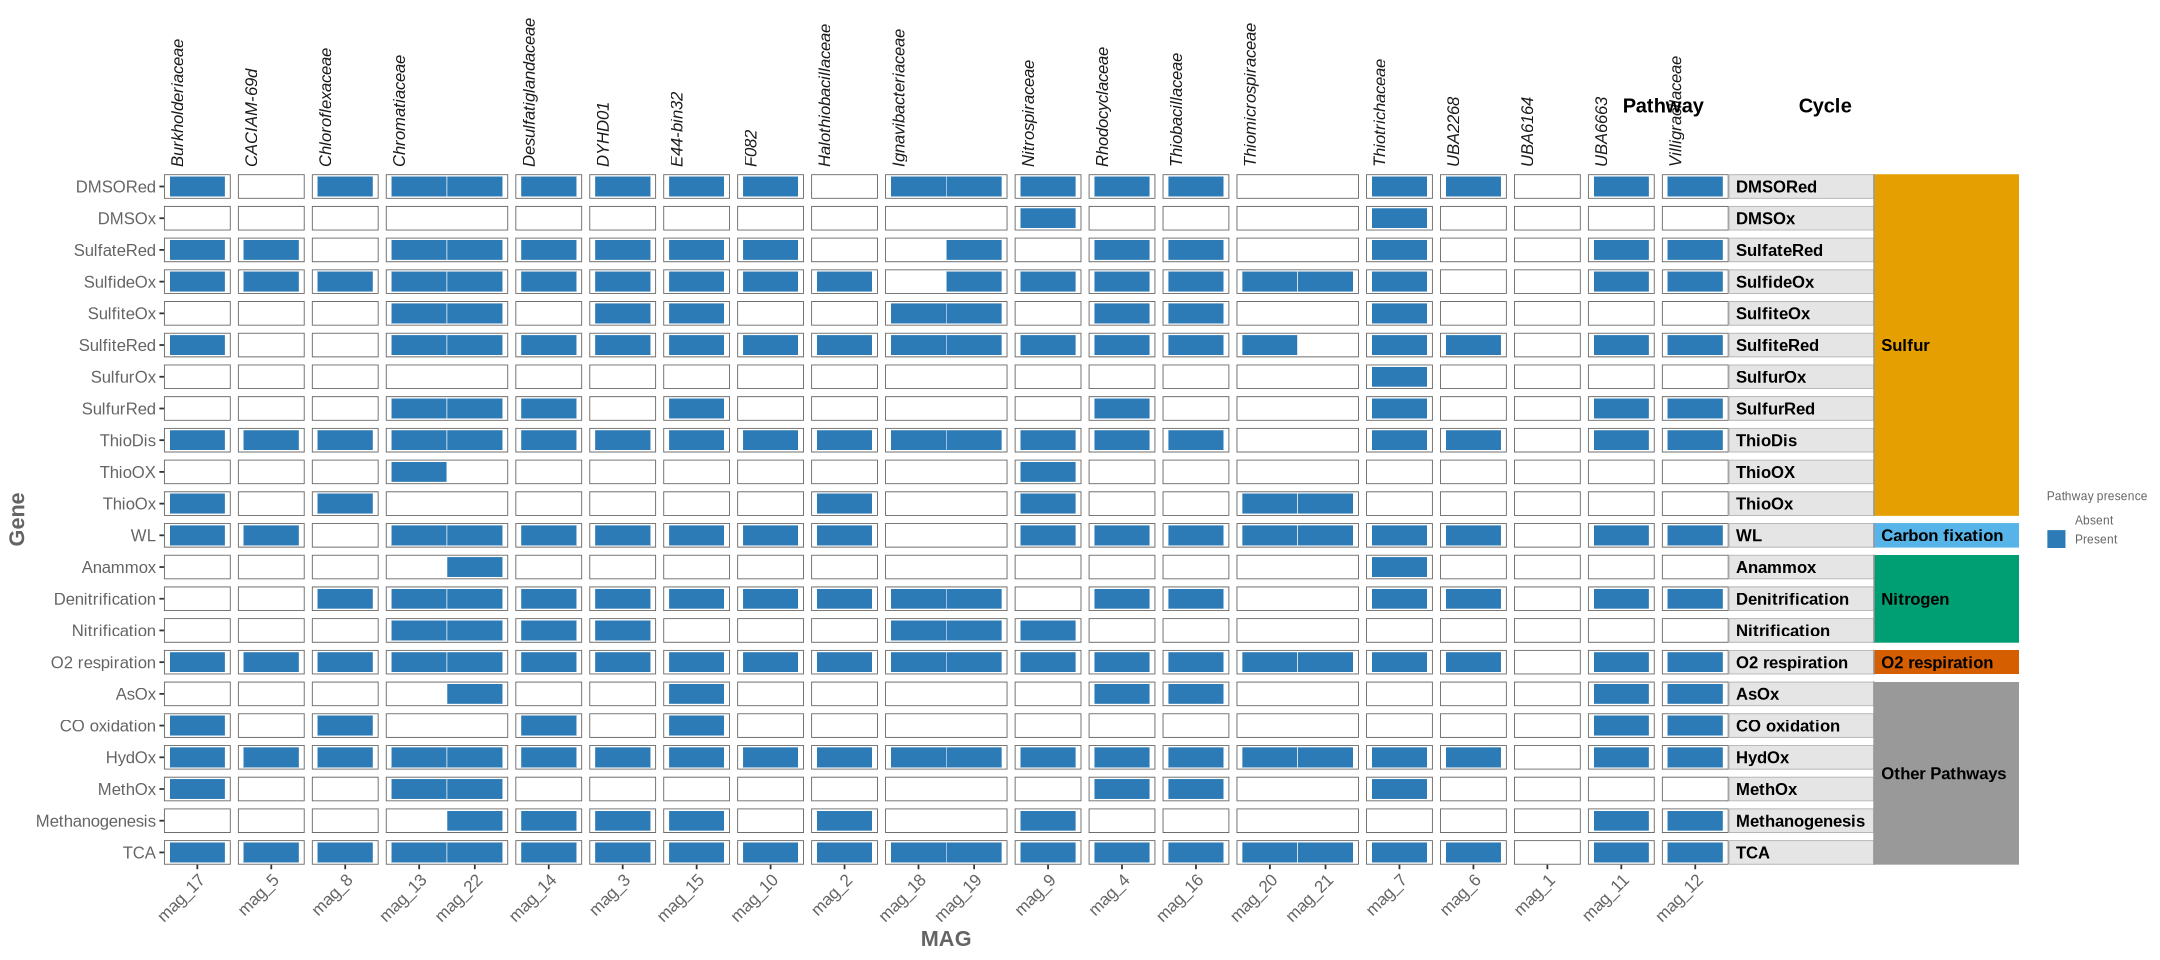

In [11]:
p_pa_titled <- ggdraw(p_pa) +
  draw_label("Pathway", x = 0.77, y = 0.89, hjust = 0.5, size = 12, fontface = "bold") +
  draw_label("Cycle",   x = 0.845, y = 0.89, hjust = 0.5, size = 12, fontface = "bold")

p_pa_titled

In [12]:
# ── Save ────────────────────────────────────────────────────────────────────
n_mags  <- n_distinct(pa_long$mag)
n_genes <- n_distinct(pa_long$pathway)
plot_width  <- max(6,  n_mags  * 0.45 + 3)
plot_height <- max(10, n_genes * 0.20 + 4)

out_file_pa <- paste0(output_dir, sample, "_pa_test_3_heatmap.png")
out_file_pa_2 <- paste0(output_dir, sample, "_pa_heatmap.svg")

ggsave(out_file_pa, plot = p_pa_titled,
       width = plot_width, height = plot_height,
       units = "in", dpi = 300, limitsize = FALSE)

ggsave(out_file_pa_2, plot = p_pa_titled,
       width = plot_width, height = plot_height,
       units = "in", dpi = 300, limitsize = FALSE)


In [13]:
library(png)
library(grid)
library(ggpubr)
img <- readPNG("~/Downloads/test_2_itol_tree.png")


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend




In [14]:
img <- as_ggplot(rasterGrob(img, interpolate = TRUE))

In [15]:
img_4 <- readPNG("~/Downloads/test_4_itol_tree.png")

itol_tree_4 <- as_ggplot(rasterGrob(img_4, interpolate = TRUE))

In [16]:
options(repr.plot.width = 10, repr.plot.height = 16)

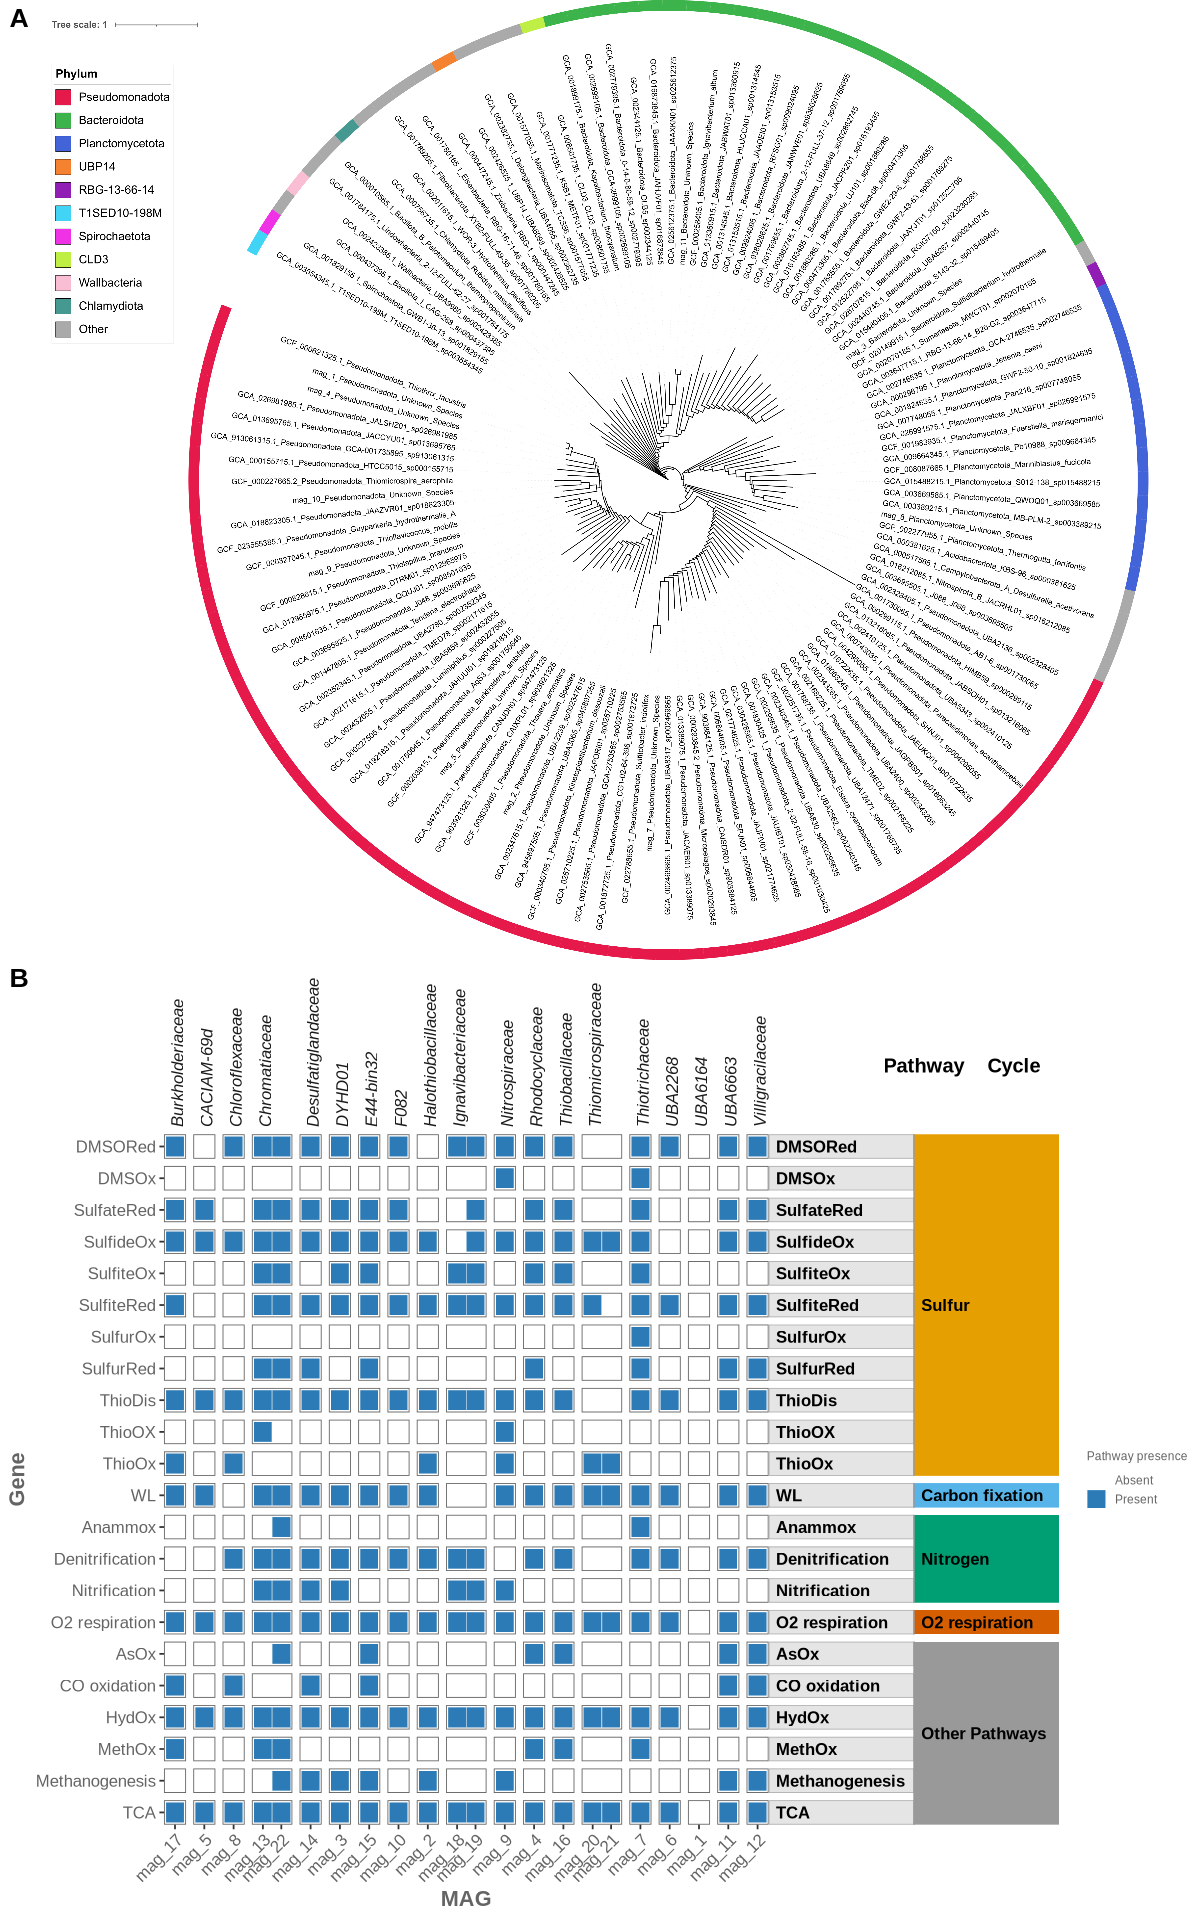

In [17]:
combined_plot <- ggarrange(
  itol_tree_4,
  p_pa_titled,
  ncol = 1,
  nrow = 2,
  labels = c("A", "B"),
  font.label = list(
    size = 16,
    face = "bold"
  ),
  common.legend = TRUE,
  legend = "right",
  align = "v"
)

combined_plot
ggsave(paste0("../figures/combined_figure_4_1.png"), combined_plot, width = 10, height = 16, dpi = 300)
ggsave(paste0("../figures/combined_figure_4_1.svg"), combined_plot, width = 10, height = 16, dpi = 300)

In [18]:
raw_img <- readPNG("~/Downloads/test_5_itol_tree.png")
print(dim(raw_img))

[1] 8586 9379    4


In [19]:
raw_img <- readPNG("~/Downloads/test_5_itol_tree.png")
# 2. Flatten alpha transparency over a white background
if (dim(raw_img)[3] == 4) {
  alpha <- raw_img[, , 4]
  for (i in 1:3) {
    # Blend RGB channels with pure white (1) using the alpha weight
    raw_img[, , i] <- raw_img[, , i] * alpha + 1 * (1 - alpha)
  }
  # Drop the 4th alpha channel to keep a clean 3-channel RGB image
  raw_img <- raw_img[, , 1:3]
}
itol_tree_5 <- as_ggplot(rasterGrob(raw_img, interpolate = TRUE))

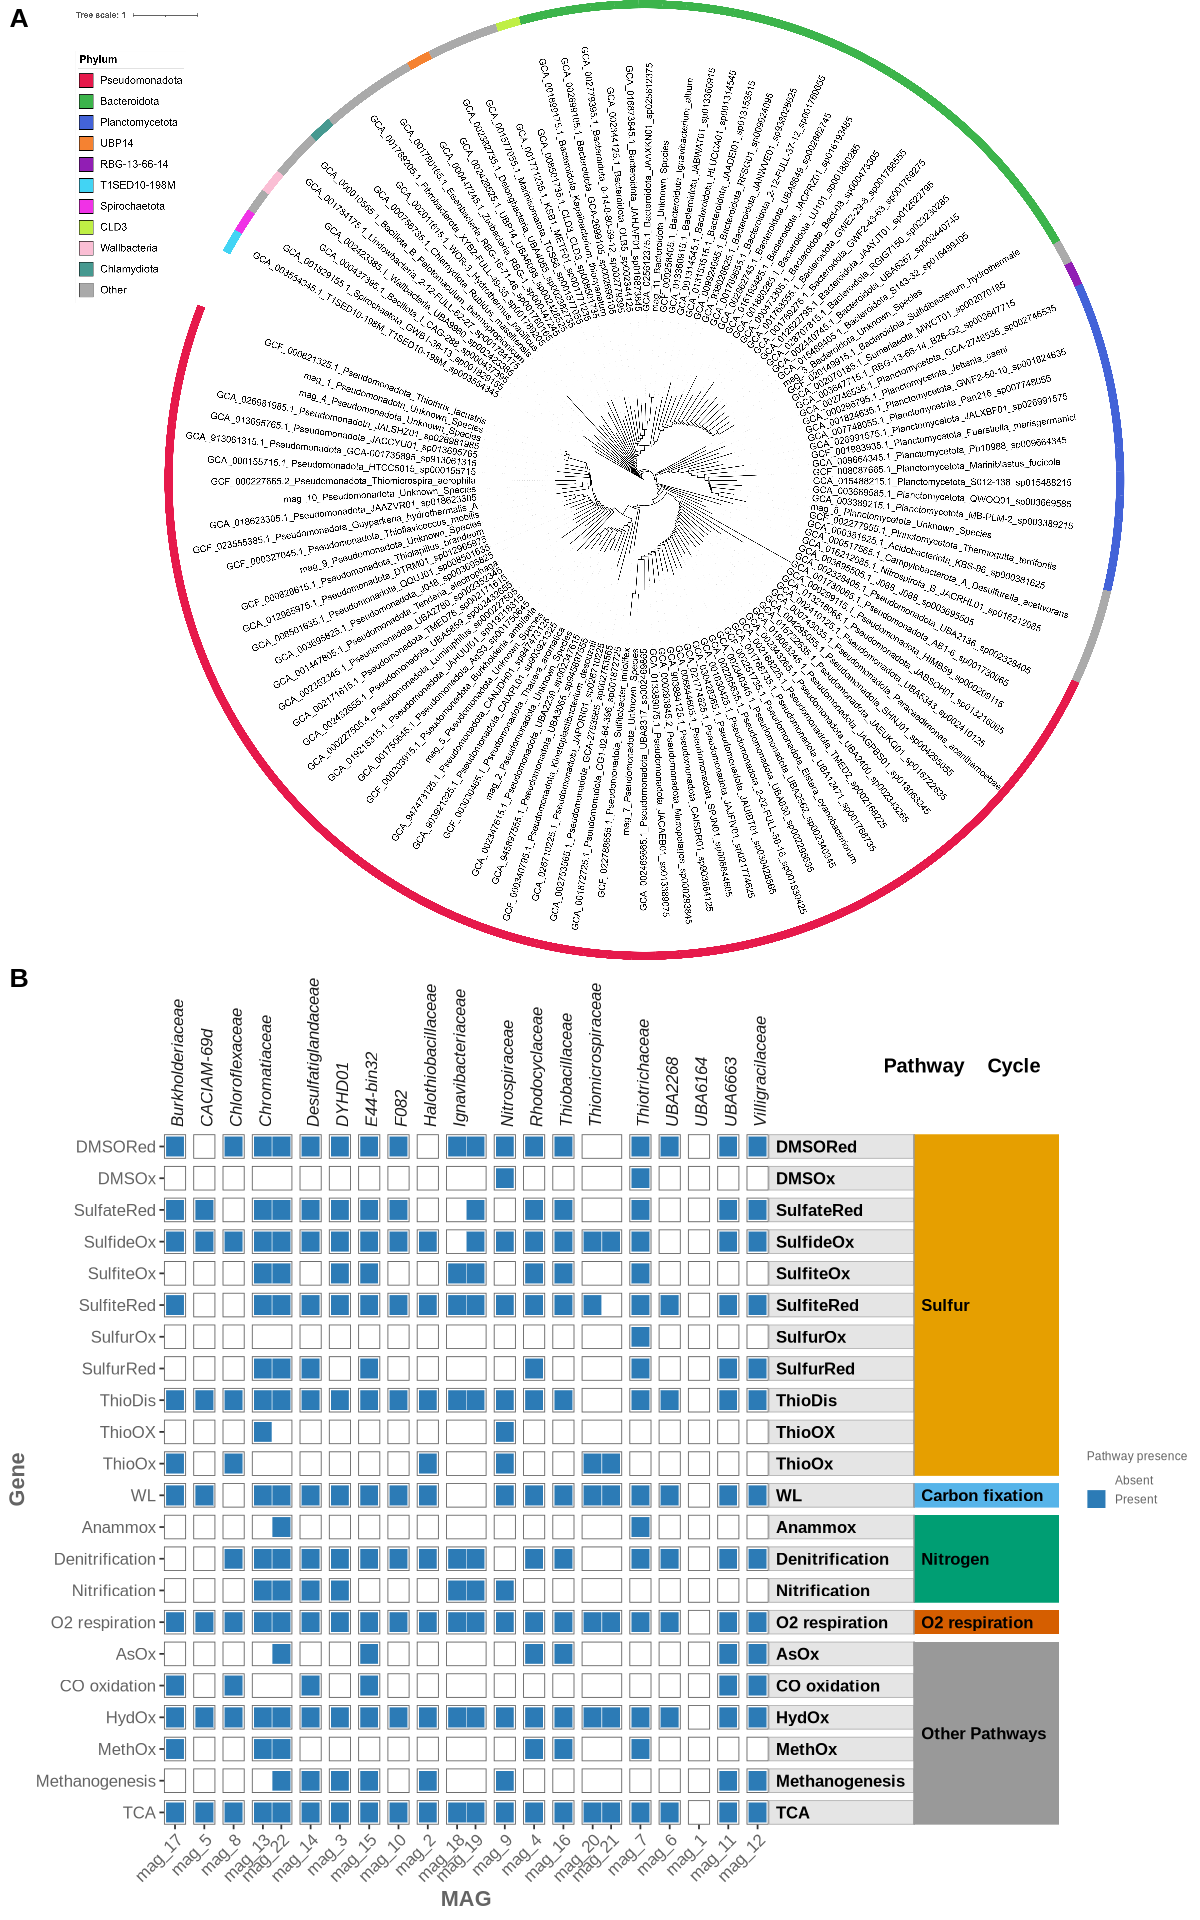

In [20]:
combined_plot <- ggarrange(
  itol_tree_5,
  p_pa_titled,
  ncol = 1,
  nrow = 2,
  labels = c("A", "B"),
  font.label = list(
    size = 16,
    face = "bold"
  ),
  common.legend = TRUE,
  legend = "right",
  align = "v"
)

combined_plot
ggsave(paste0("../figures/combined_figure_5_1.png"), combined_plot, width = 10, height = 16, dpi = 300)
ggsave(paste0("../figures/combined_figure_5_1.svg"), combined_plot, width = 10, height = 16, dpi = 300)